In [ ]:
import numpy as np

In [ ]:
a=np.array(4)
a

array(4)

In [ ]:
a.ndim

0

In [ ]:
arr=np.array([1,2,3,4,5])

In [ ]:
arr

array([1, 2, 3, 4, 5])

In [ ]:
arr.ndim

1

In [ ]:
mat=np.array([[1,2,3],[4,5,6],[7,8,9]])
mat

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [ ]:
mat.ndim

2

In [ ]:
import numpy as np
import pandas as pd



In [ ]:
df=pd.read_csv('placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.shape

(100, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
df=df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


EDA

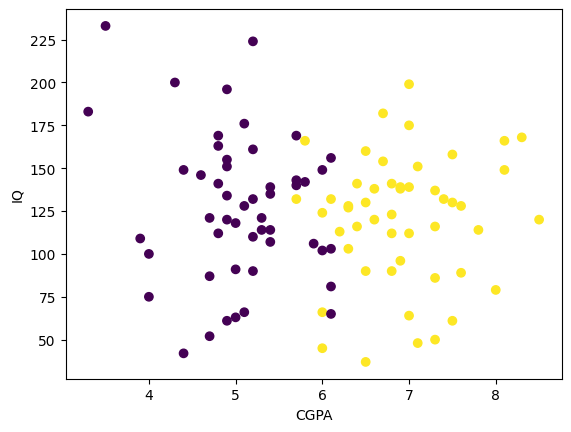

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df["cgpa"],df["iq"],c=df["placement"])
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.show()

In [ ]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
Y.shape

(100,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [ ]:
X_train

,cgpa,iq
68,4.0,75.0
56,6.1,65.0
93,6.8,112.0
51,4.8,141.0
11,6.9,138.0
...,...,...
9,5.1,66.0
20,6.6,120.0
79,6.5,90.0
81,5.4,107.0


In [ ]:
X_test

,cgpa,iq
90,7.3,86.0
85,5.8,166.0
74,6.7,154.0
65,8.1,166.0
26,7.0,199.0
73,4.9,61.0
22,4.9,120.0
96,4.4,42.0
0,6.8,123.0
71,6.1,132.0


In [ ]:
Y_train

,placement
68,0
56,0
93,1
51,0
11,1
...,...
9,0
20,1
79,1
81,0


In [ ]:
Y_test

,placement
90,1
85,1
74,1
65,1
26,1
73,0
22,0
96,0
0,1
71,1


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
X_train=scaler.fit_transform(X_train)

In [ ]:
X_train

array([[-1.73225904, -1.24742355],
       [ 0.11639685, -1.50497831],
       [ 0.73261548, -0.29447094],
       [-1.02800917,  0.45243786],
       [ 0.82064672,  0.37517143],
       [-0.85194671, -1.55648926],
       [ 0.90867795, -1.53073378],
       [-1.20407164,  0.58121524],
       [-1.38013411,  0.65848167],
       [ 0.90867795,  0.40092691],
       [ 1.61292781, -0.24295999],
       [-0.23572808,  1.17359119],
       [-0.58785301, -0.24295999],
       [-0.76391548,  1.35387952],
       [-0.67588424,  2.59014236],
       [ 1.34883411, -1.60800021],
       [-1.02800917,  1.17359119],
       [ 0.11639685, -0.52627022],
       [ 1.34883411,  0.89028095],
       [ 0.46852178,  0.9417919 ],
       [-0.14769685,  0.47819334],
       [ 0.99670918, -1.9428214 ],
       [ 0.73261548,  0.45243786],
       [ 0.55655302,  0.37517143],
       [ 2.05308397,  1.14783571],
       [ 0.29245932,  0.0918612 ],
       [ 1.43686535,  0.11761667],
       [ 1.78899028, -1.14440165],
       [ 1.17277165,

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf=LogisticRegression()


In [ ]:
# model training
clf.fit(X_train,Y_train)

LogisticRegression()

In [ ]:
Y_pred=clf.predict(X_test)
Y_pred

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


array([1, 0, 0, 0, 0, 1, 0, 1, 0, 0])

In [ ]:
Y_test

,placement
90,1
85,1
74,1
65,1
26,1
73,0
22,0
96,0
0,1
71,1


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(Y_test,Y_pred)

0.2

Drawing a decision boundary

<Axes: >

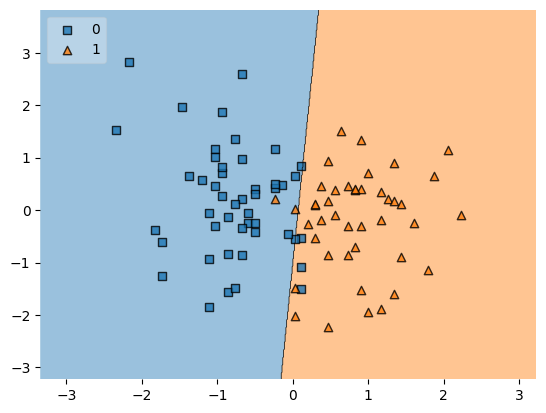

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train,Y_train.values,clf=clf,legend=2)

In [ ]:
import pickle
pickle.dump(clf,open("model.pkl","wb"))